In [1]:
import keras
from keras.utils import plot_model, custom_object_scope
from keras_self_attention import SeqSelfAttention
import os

# Base path for models
BASE_PATH = "../complete workflow/pdf-nn-data/models"

# Available models
MODELS = {
    "th_clusters": os.path.join(BASE_PATH, "th_clusters/tuned_sliced_th_calc_2-12_retrain.h5"),
    "ce_clusters": os.path.join(BASE_PATH, "ce_clusters/tuned_sliced_ce_calc_2-12_retrain.h5"),
    "csd": os.path.join(BASE_PATH, "csd/tuned_csd_2-12.h5"),
}

# Output directory for figures
OUTPUT_DIR = "../complete workflow/pdf-nn-data/results/figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [2]:
# Load the Th clusters model
with custom_object_scope({'SeqSelfAttention': SeqSelfAttention}):
    th_model = keras.models.load_model(MODELS["th_clusters"])
print(f"Loaded: {MODELS['th_clusters']}")

Loaded: ../complete workflow/pdf-nn-data/models/th_clusters/tuned_sliced_th_calc_2-12_retrain.h5


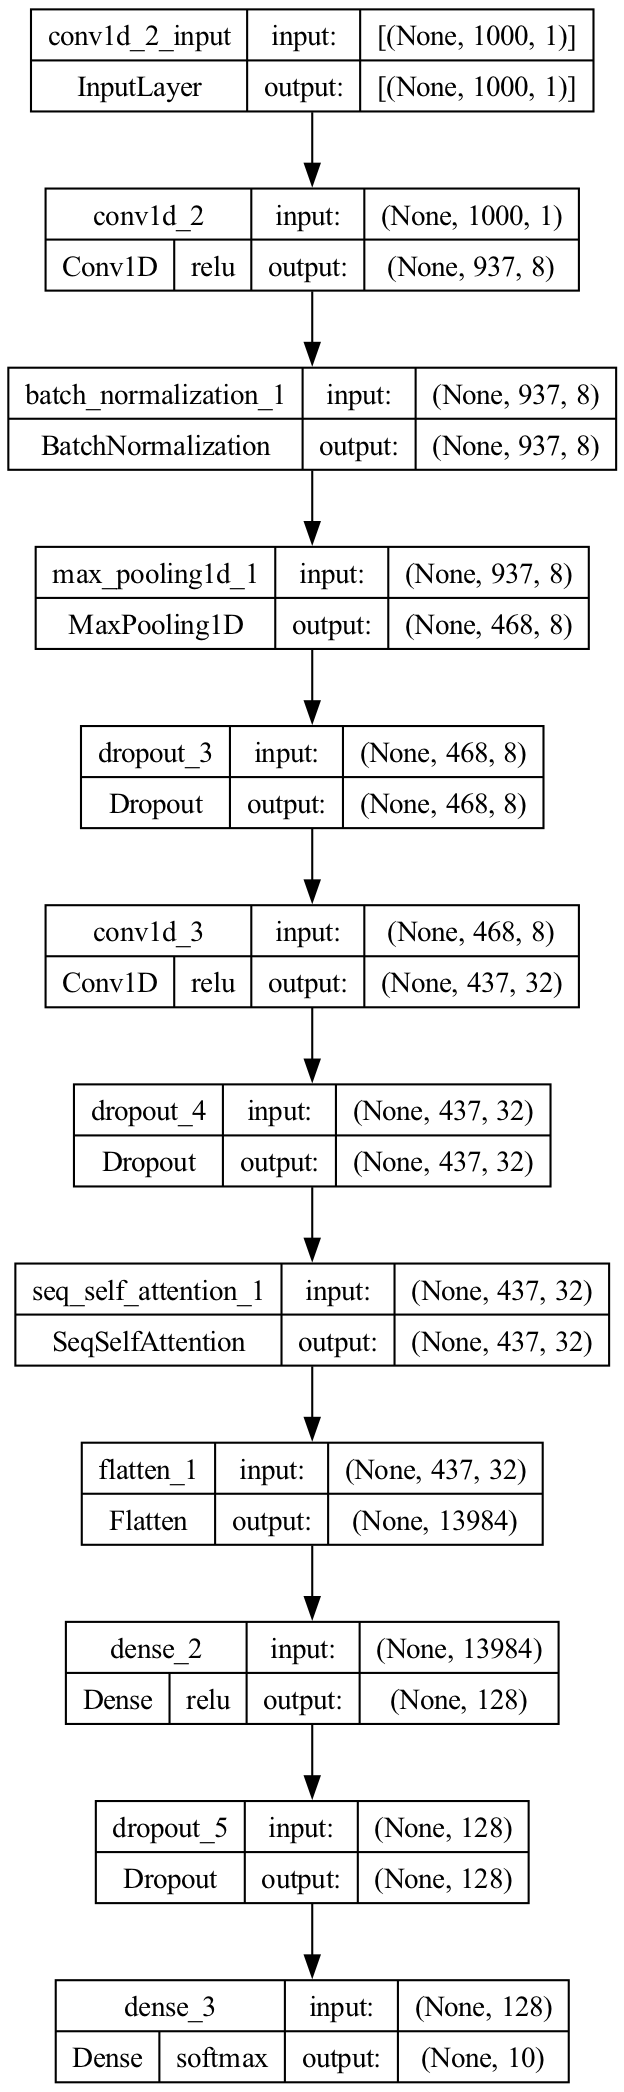

In [3]:
# Plot model architecture using Keras plot_model (vertical layout)
plot_model(
    th_model,
    to_file=os.path.join(OUTPUT_DIR, "th_model_architecture.png"),
    show_shapes=True,
    show_dtype=False,
    show_layer_names=True,
    rankdir="TB",  # Top to Bottom
    expand_nested=True,
    dpi=150,
    show_layer_activations=True
)

In [4]:
# Model summary
th_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_2 (Conv1D)           (None, 937, 8)            520       
                                                                 
 batch_normalization_1 (Batc  (None, 937, 8)           32        
 hNormalization)                                                 
                                                                 
 max_pooling1d_1 (MaxPooling  (None, 468, 8)           0         
 1D)                                                             
                                                                 
 dropout_3 (Dropout)         (None, 468, 8)            0         
                                                                 
 conv1d_3 (Conv1D)           (None, 437, 32)           8224      
                                                                 
 dropout_4 (Dropout)         (None, 437, 32)          

In [5]:
# Load the CSD model
with custom_object_scope({'SeqSelfAttention': SeqSelfAttention}):
    csd_model = keras.models.load_model(MODELS["csd"])
print(f"Loaded: {MODELS['csd']}")

Loaded: ../complete workflow/pdf-nn-data/models/csd/tuned_csd_2-12.h5


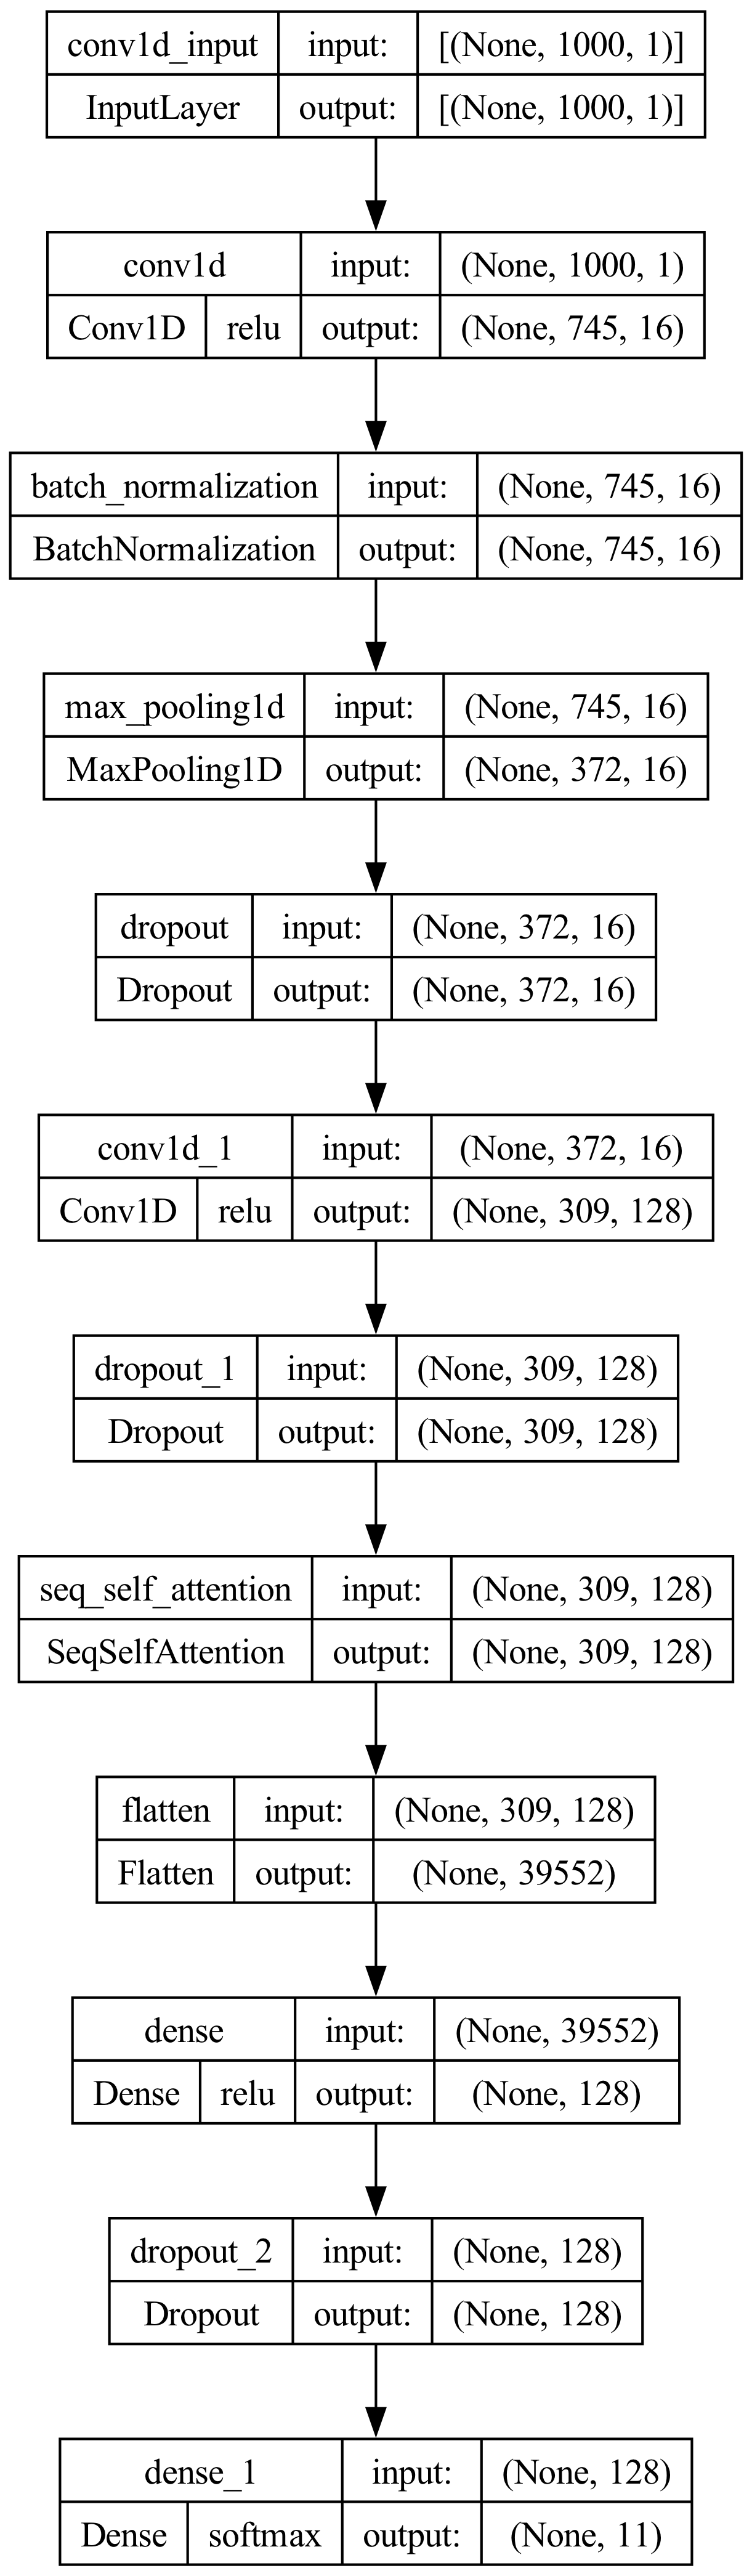

In [6]:
# Plot CSD model architecture (high resolution)
plot_model(
    csd_model,
    to_file=os.path.join(OUTPUT_DIR, "csd_model_architecture.png"),
    show_shapes=True,
    show_dtype=False,
    show_layer_names=True,
    rankdir="TB",
    expand_nested=True,
    dpi=300,
    show_layer_activations=True
)

In [7]:
# Load Ce clusters model
with custom_object_scope({'SeqSelfAttention': SeqSelfAttention}):
    ce_model = keras.models.load_model(MODELS["ce_clusters"])
print(f"Loaded: {MODELS['ce_clusters']}")

Loaded: ../complete workflow/pdf-nn-data/models/ce_clusters/tuned_sliced_ce_calc_2-12_retrain.h5


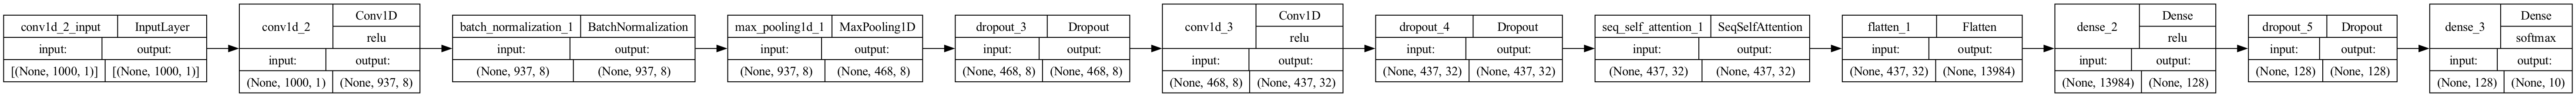

In [8]:
# Horizontal layout (Left-to-Right) - cleaner for presentations
plot_model(
    th_model,
    to_file=os.path.join(OUTPUT_DIR, "th_model_horizontal.png"),
    show_shapes=True,
    show_dtype=False,
    show_layer_names=True,
    rankdir="LR",  # Left to Right
    expand_nested=False,
    dpi=150,
    show_layer_activations=True
)

/Users/dimitrygrebenyuk/miniforge3/envs/keras/lib/python3.9/site-packages/visualkeras/layered.py:86: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


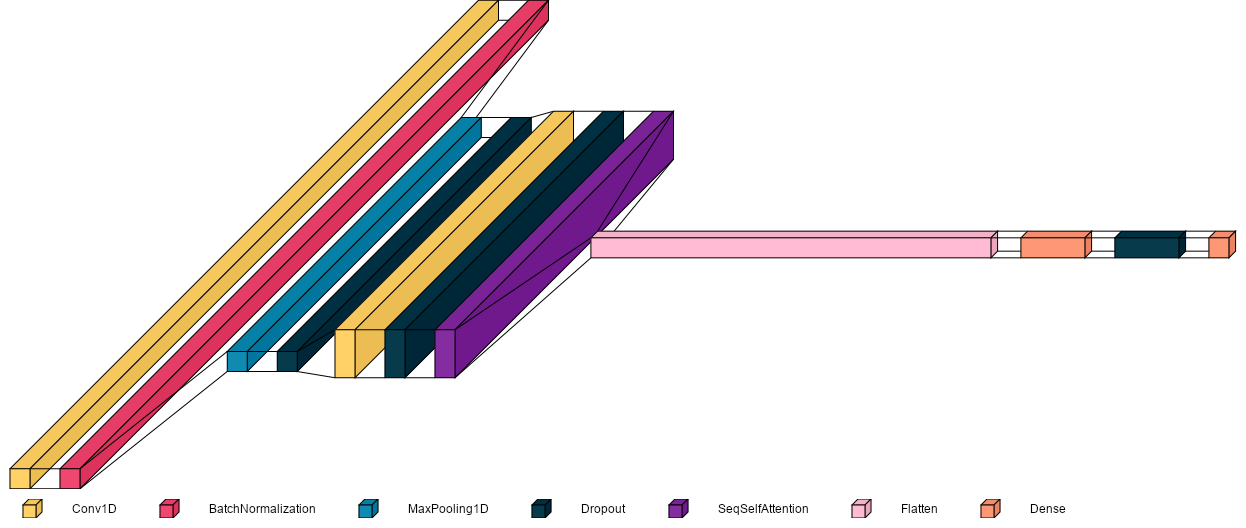

In [ ]:
# Visualize with visualkeras for a more aesthetic representation

import visualkeras
from PIL import ImageFont

# Try to use a nicer font (falls back to default if not available)
try:
    font = ImageFont.truetype("Arial", 12)
except:
    font = None

visualkeras.layered_view(
    th_model, 
    to_file=os.path.join(OUTPUT_DIR, 'th_model_visualkeras.png'),
    legend=True,
    font=font,
    scale_xy=1.5,
    scale_z=0.5,
    spacing=30
)

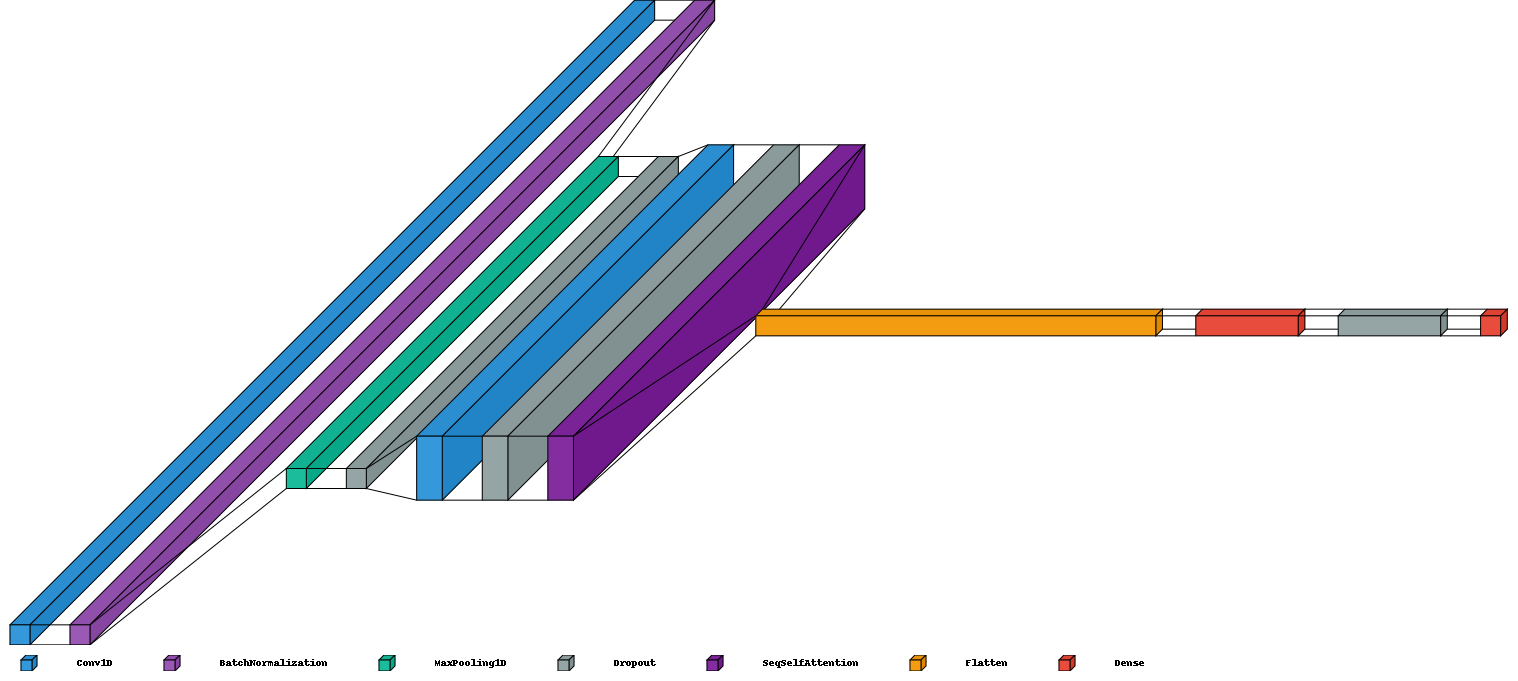

In [10]:
# ============================================================
# CUSTOM COLORED VISUALIZATION (Publication-ready)
# ============================================================
from tensorflow.keras import layers
from collections import defaultdict

# Define custom color mapping for different layer types
color_map = defaultdict(dict)
color_map[layers.Conv1D]['fill'] = '#3498db'      # Blue for Conv
color_map[layers.Dense]['fill'] = '#e74c3c'        # Red for Dense
color_map[layers.LSTM]['fill'] = '#2ecc71'         # Green for LSTM
color_map[layers.Dropout]['fill'] = '#95a5a6'      # Gray for Dropout
color_map[layers.BatchNormalization]['fill'] = '#9b59b6'  # Purple for BatchNorm
color_map[layers.Flatten]['fill'] = '#f39c12'      # Orange for Flatten
color_map[layers.MaxPooling1D]['fill'] = '#1abc9c' # Teal for Pooling
color_map[layers.Concatenate]['fill'] = '#e67e22'  # Dark Orange for Concat

# Create styled visualization
visualkeras.layered_view(
    th_model,
    to_file=os.path.join(OUTPUT_DIR, 'th_model_styled.png'),
    legend=True,
    color_map=color_map,
    scale_xy=2,
    scale_z=0.8,
    spacing=40,
    draw_volume=True
)

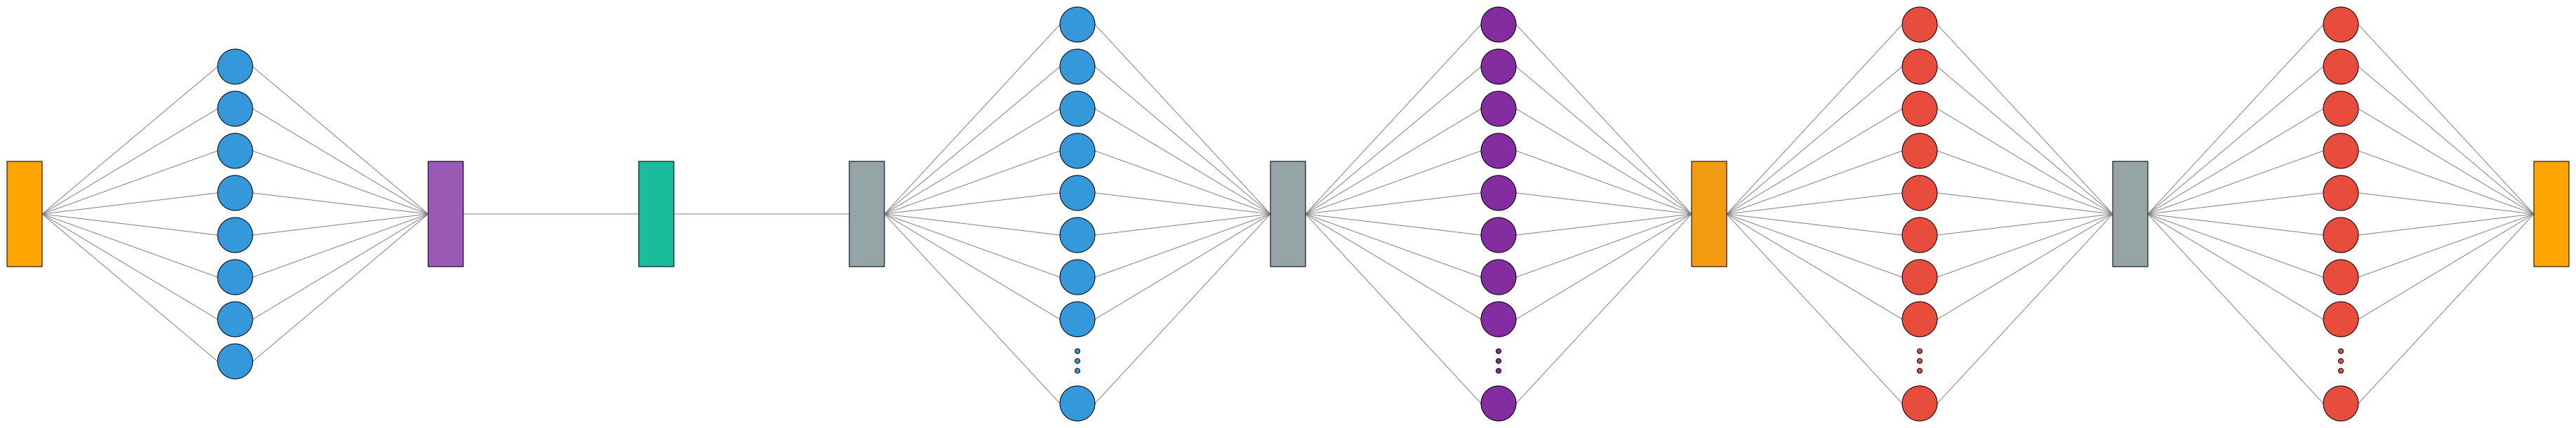

In [11]:
# ============================================================
# GRAPH-BASED VISUALIZATION (Alternative style)
# ============================================================
# This creates a more technical graph representation

visualkeras.graph_view(
    th_model,
    to_file=os.path.join(OUTPUT_DIR, 'th_model_graph.png'),
    color_map=color_map
)

## Compare All Models Side by Side

Generate visualizations for all three trained models (Th clusters, Ce clusters, CSD) for comparison.

In [12]:
# Generate visualizations for all models
import matplotlib.pyplot as plt
from matplotlib.image import imread

models_dict = {
    "Th Clusters": th_model,
    "Ce Clusters": ce_model, 
    "CSD": csd_model
}

# Generate layered views for all models
for name, model in models_dict.items():
    filename = f"{name.lower().replace(' ', '_')}_layered.png"
    visualkeras.layered_view(
        model,
        to_file=os.path.join(OUTPUT_DIR, filename),
        legend=True,
        color_map=color_map,
        scale_xy=1.5,
        scale_z=0.5,
        spacing=30,
        draw_volume=True
    )
    print(f"Generated: {filename}")

Generated: th_clusters_layered.png
Generated: ce_clusters_layered.png
Generated: csd_layered.png


/Users/dimitrygrebenyuk/miniforge3/envs/keras/lib/python3.9/site-packages/visualkeras/layered.py:86: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


In [13]:
# Display model summaries comparison
print("=" * 80)
for name, model in models_dict.items():
    print(f"\n{name} Model")
    print("-" * 40)
    print(f"Total parameters: {model.count_params():,}")
    print(f"Trainable parameters: {sum([layer.count_params() for layer in model.layers if layer.trainable]):,}")
    print(f"Number of layers: {len(model.layers)}")
print("=" * 80)


Th Clusters Model
----------------------------------------
Total parameters: 1,801,171
Trainable parameters: 1,801,171
Number of layers: 11

Ce Clusters Model
----------------------------------------
Total parameters: 3,473,355
Trainable parameters: 3,473,355
Number of layers: 11

CSD Model
----------------------------------------
Total parameters: 5,215,964
Trainable parameters: 5,215,964
Number of layers: 11
